# Sensitivity Analysis for SoftwareX Paper

This notebooks performs a sensitivity analysis for selected parameters for use case A included in the paper's illustrative example section.

In [ ]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd

from lift.backend.scenario import ScenarioResult, SingleScenario
from lift.utils import read_csv

In [ ]:
df = read_csv(Path("case_a.csv"), transpose=True)


def sensitivity_analysis(
    baseline: pd.Series,
    parameter: tuple[str, str],
    variation: npt.NDArray,
) -> dict[str, ScenarioResult]:
    rows = []
    for value in variation:
        row = baseline.copy()
        row[parameter] = value
        rows.append(row)

    df_varied = pd.DataFrame(data=rows, index=["_".join((*parameter, str(value))) for value in variation])

    return {scn: SingleScenario.from_series(scn_series).simulate() for scn, scn_series in df_varied.iterrows()}


capacities_ess = np.linspace(0, 1000e3, 20)

results_ess = sensitivity_analysis(
    baseline=df.loc["cost3", :],
    parameter=("ess", "capacity"),
    variation=capacities_ess,
)

Scenario simulation time: 0.2404 s
Scenario simulation time: 0.2344 s
Scenario simulation time: 0.2426 s
Scenario simulation time: 0.2441 s
Scenario simulation time: 0.2491 s
Scenario simulation time: 0.2445 s
Scenario simulation time: 0.2414 s
Scenario simulation time: 0.2432 s
Scenario simulation time: 0.2396 s
Scenario simulation time: 0.2521 s
Scenario simulation time: 0.2470 s
Scenario simulation time: 0.2534 s
Scenario simulation time: 0.2440 s
Scenario simulation time: 0.2461 s
Scenario simulation time: 0.2520 s
Scenario simulation time: 0.2580 s
Scenario simulation time: 0.2498 s
Scenario simulation time: 0.2436 s
Scenario simulation time: 0.2411 s
Scenario simulation time: 0.2524 s


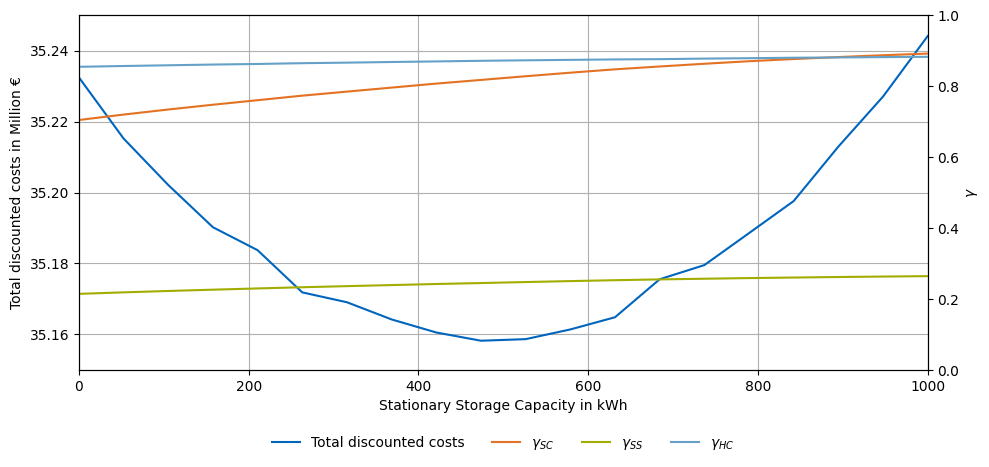

In [ ]:
df_results_ess = pd.DataFrame.from_dict(
    {
        k: {
            "totex": v.totex_dis.sum(),
            "capex": v.capex_dis.sum(),
            "opex": v.opex_dis.sum(),
            "gamma_sc": v.self_consumption,
            "gamma_ss": v.self_sufficiency,
            "gamma_hc": v.home_charging_fraction,
        }
        for k, v in results_ess.items()
    },
    orient="index",
)

COLORS = {
    "p300c": (0.0, 0.396078431372549, 0.7411764705882353),
    "p158": (0.8901960784313725, 0.4470588235294118, 0.13333333333333333),
    "p383": (0.6352941176470588, 0.6784313725490196, 0.0),
    "p542": (0.39215686274509803, 0.6274509803921569, 0.7843137254901961),
}

fig, ax1 = plt.subplots(figsize=(10, 5))

x = capacities_ess * 1e-3

# --- Left y-axis: costs ---
ax1.plot(x, df_results_ess["totex"] / 1e6, label="Total discounted costs", color=COLORS["p300c"])


# --- Right y-axis: fractions ---
ax2 = ax1.twinx()

ax2.plot(x, df_results_ess["gamma_sc"], label=r"$\gamma_{SC}$", color=COLORS["p158"])

ax2.plot(x, df_results_ess["gamma_ss"], label=r"$\gamma_{SS}$", color=COLORS["p383"])

ax2.plot(x, df_results_ess["gamma_hc"], label=r"$\gamma_{HC}$", color=COLORS["p542"])


ax1.set_xlabel("Stationary Storage Capacity in kWh")
ax1.set_xlim(0.0, 1000.0)
ax1.set_ylabel("Total discounted costs in Million €")
ax1.set_ylim(35.15, 35.25)
ax2.set_ylabel(r"$\gamma$")
ax2.set_ylim(0.0, 1.0)
ax1.grid(True)

# --- Combined legend ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

ax1.legend(
    lines_1 + lines_2, labels_1 + labels_2, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()